In [ ]:
%reload_ext autoreload
%autoreload 2

from src.path_plotters import (
    describe_path_features,
    load_neptus_paths,
    plot_mission_path,
    select_path,
    create_usable_area,
    create_path_sections,
    create_path_coverage
)

from shapely.geometry import Polygon
import geopandas as gpd


In [4]:
paths_1 = load_neptus_paths("data/raw/marie_mission1_path.geojson")
describe_path_features(paths_1)


,name,description,geometry
0,lauv-marie,executed path Sun Sep 06 12:10:10 CEST 2026,"LINESTRING Z (17.3615 78.45063 -8.41615, 17.36..."
1,waypoints,desired path Sun Sep 06 12:10:10 CEST 2026,"LINESTRING Z (17.36142 78.45065 0, 17.36142 78..."


In [5]:
paths_2 = load_neptus_paths("data/raw/marie_mission2_path.geojson")
describe_path_features(paths_2)

,name,description,geometry
0,lauv-marie,executed path Sun Sep 06 12:41:36 CEST 2026,"LINESTRING Z (17.36159 78.45029 -9.66375, 17.3..."
1,waypoints,desired path Sun Sep 06 12:41:36 CEST 2026,"LINESTRING Z (17.36192 78.4502 0, 17.36192 78...."


mission1 [17.36141627 78.44932381 17.38116233 78.45191181]
mission2 [17.3619232  78.44935461 17.37463956 78.45062632]


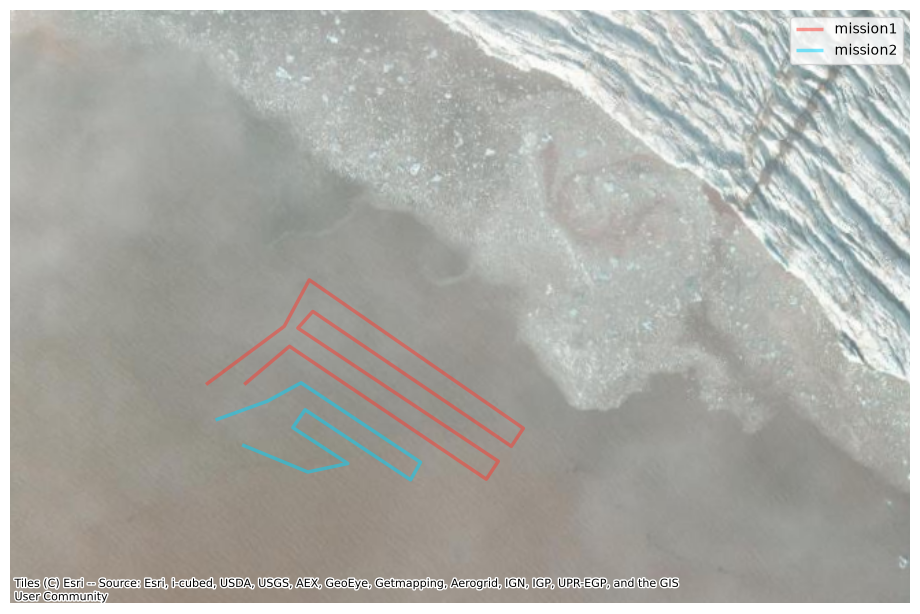

In [57]:
# planned missions
planned_path_1 = select_path(paths_1, "waypoints")
planned_path_2 = select_path(paths_2, "waypoints")

# print(executed_path.to_crs("EPSG:4326").total_bounds)

fig, ax = plot_mission_path(
    paths={"mission1": planned_path_1, "mission2": planned_path_2},
    output_file="data/output/marie_planned_path.png",
    bounds=(17.35, 78.448, 17.405, 78.455)
)

mission1_waypoints [17.36141627 78.44932381 17.38116233 78.45191181]
mission2_waypoints [17.3619232  78.44935461 17.37463956 78.45062632]
mission1_actual [17.36136554 78.44934076 17.38109486 78.45210199]
mission2_actual [17.35962011 78.44936529 17.37458383 78.45081262]


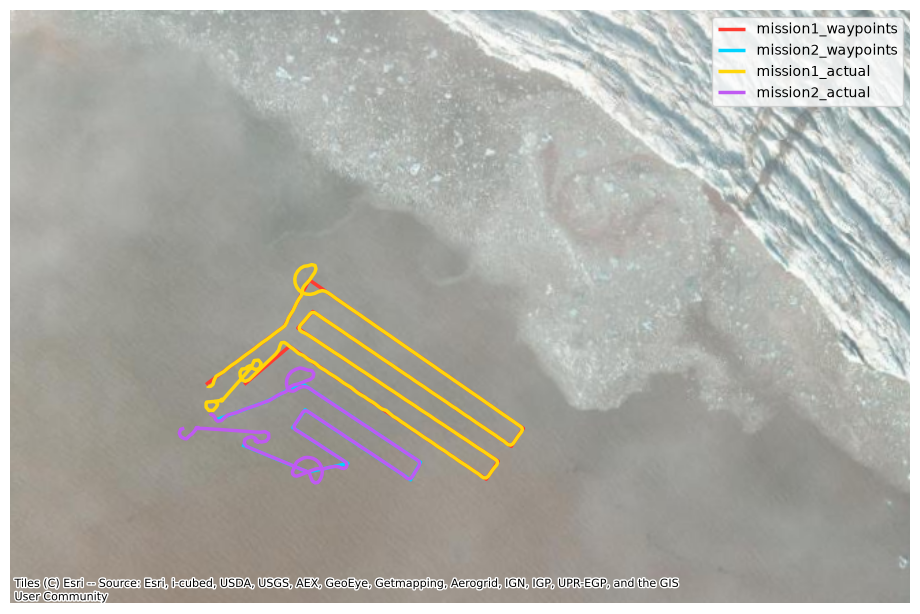

In [59]:
# executed paths
actual_path_1 = select_path(paths_1, "lauv-marie")
actual_path_2 = select_path(paths_2, "lauv-marie")

# print(executed_path.to_crs("EPSG:4326").total_bounds)

fig, ax = plot_mission_path(
    paths={"mission1_waypoints": planned_path_1, "mission2_waypoints": planned_path_2,
        "mission1_actual": actual_path_1, "mission2_actual": actual_path_2},
    output_file="data/output/marie_actual_path.png",
    bounds=(17.35, 78.448, 17.405, 78.455)
)

mission1 [17.36136554 78.44934076 17.38109486 78.45210199]
mission2 [17.35962011 78.44936529 17.37458383 78.45081262]


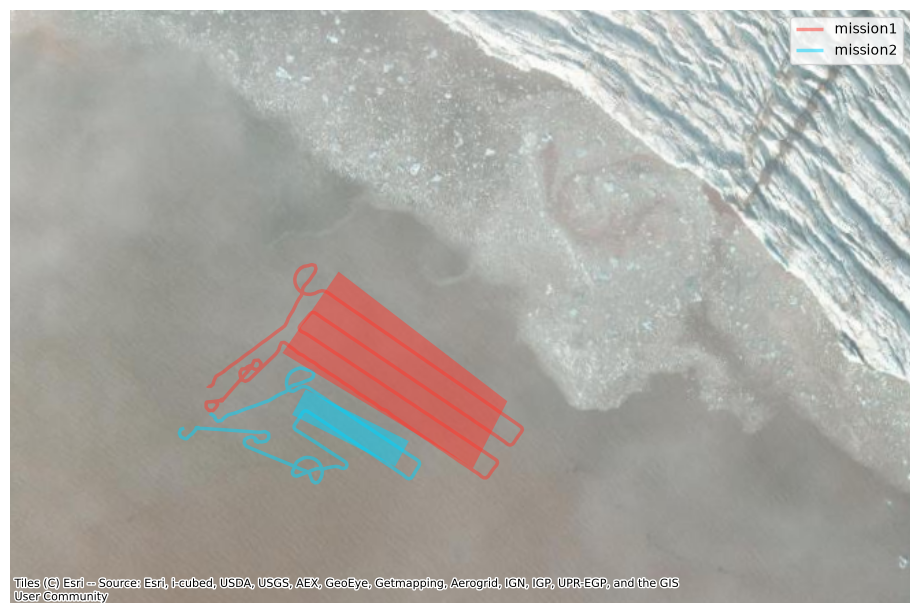

In [23]:
mission1_area = gpd.GeoDataFrame(
    geometry=[Polygon([
        (17.37, 78.452),
        (17.38023, 78.45029),
        (17.37791, 78.44947),
        (17.36628, 78.45101),
    ])],
    crs="EPSG:4326",
)

mission2_area = gpd.GeoDataFrame(
    geometry=[Polygon([
        (17.36764, 78.45054),
        (17.37396, 78.44984),
        (17.37304, 78.44953),
        (17.36672, 78.45023),
    ])],
    crs="EPSG:4326",
)

fig, ax = plot_mission_path(paths={"mission1": actual_path_1, "mission2": actual_path_2},
    areas={"m1":mission1_area, "m2": mission2_area},
    bounds=(17.35, 78.448, 17.405, 78.455)
)

mission1 [17.36136554 78.44934076 17.38109486 78.45210199]
mission2 [17.35962011 78.44936529 17.37458383 78.45081262]


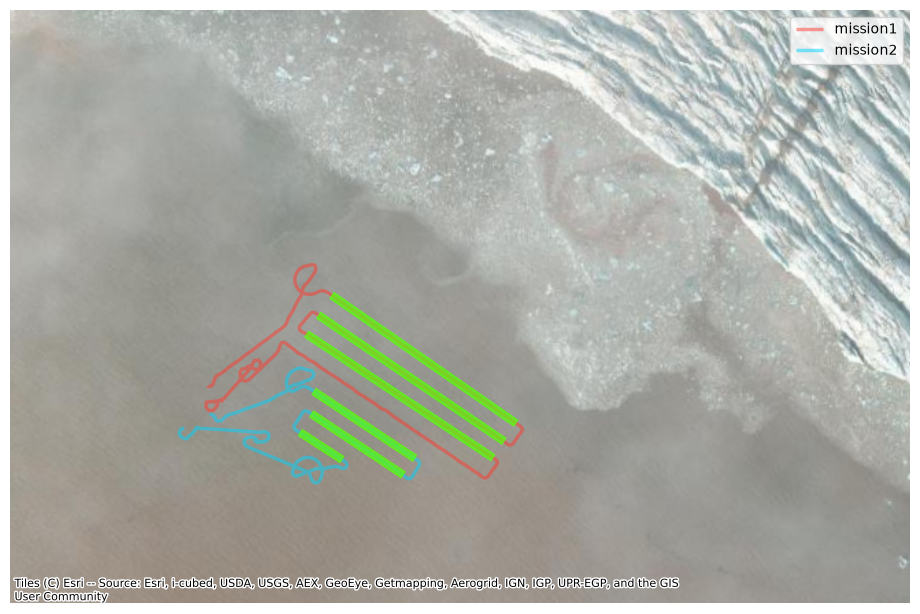

In [ ]:
# paths we will accept
mission1_sections = [
    (63, 142),
    (156, 236),
    (250, 329),
]

mission2_sections = [
    (55, 97),
    (110, 148),
    (162, 179),
]

mission1_area = create_usable_area(
    actual_path_1,
    sections=mission1_sections,
    buffer_metres=5
)

mission2_area = create_usable_area(
    actual_path_2,
    mission2_sections,
    buffer_metres=5
)

areas = {
    "mission1": mission1_area,
    "mission2": mission2_area,
}

fig, ax = plot_mission_path(
    paths={"mission1": actual_path_1, "mission2": actual_path_2},
    areas=areas,
    bounds=(17.35, 78.448, 17.405, 78.455)
)

mission1 [17.36136554 78.44934076 17.38109486 78.45210199]
mission2 [17.35962011 78.44936529 17.37458383 78.45081262]


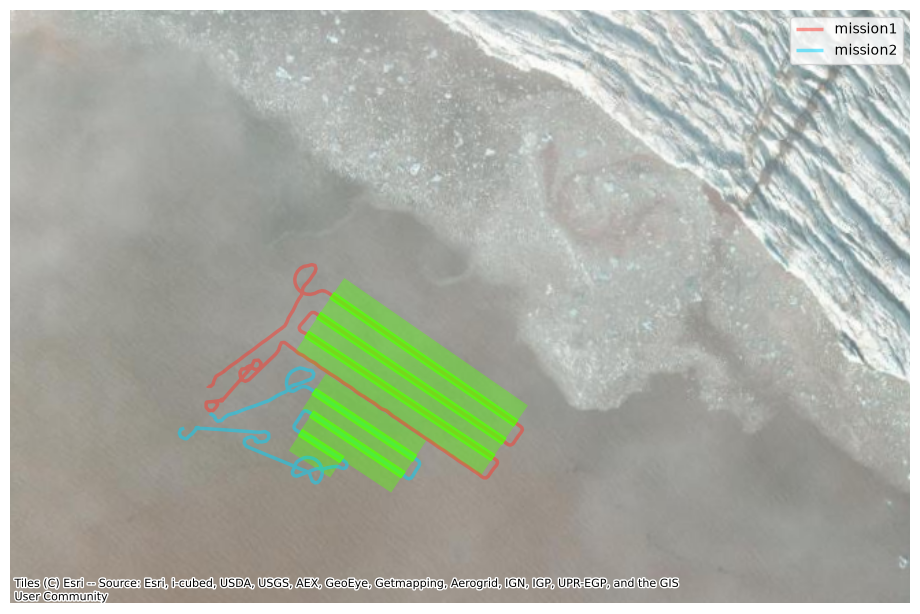

In [54]:
# path coverage and acceptance

accepted_paths = {
    "mission1": create_path_sections(
        actual_path_1,
        mission1_sections,
    ),
    "mission2": create_path_sections(
        actual_path_2,
        mission2_sections,
    ),
}

coverage = {
    "mission1": create_usable_area(
        actual_path_1,
        sections=mission1_sections,
        buffer_metres=30,
    ),
    "mission2": create_usable_area(
        actual_path_2,
        sections=mission2_sections,
        buffer_metres=30,
    ),
}

coverage_areas = {
    label: create_path_coverage(path, distance=30)
    for label, path in accepted_paths.items()
}

fig, ax = plot_mission_path(
    paths={
        "mission1": actual_path_1,
        "mission2": actual_path_2,
    },
    areas=areas,
    coverage=coverage,
    bounds=(17.35, 78.448, 17.405, 78.455),
    output_file="data/output/marie_accepted_path_and coverage.png",
)
